# Function 2: Part 2 analysis notebook

This notebook keeps the original data-loading cells, appends the latest query point/output from the end of your uploaded notebook, and then runs one focused analysis for Part 2.

Assumption: lower output is better, so the optimisation target is minimisation.


In [ ]:
import numpy as np

input_data = np.load('../../data/initial_data/function_2/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.759048, 0.965375],
    [0.714910, 0.858164],
    [0.5, 0.5],
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (10, 2)
After: (12, 2)
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.759048   0.965375  ]
 [0.71491    0.858164  ]]


In [ ]:
output_data = np.load('../../data/initial_data/function_2/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    0.29645067004988124,
    0.4598605438093154,
    0.7881941889678203
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (10,)
After: (12,)
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.29645067  0.45986054]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Latest query/output extracted from the uploaded notebook.
# Edit these if you later receive a different portal output.
latest_query = np.array([[0.5, 0.5]])
actual_output = 0.7881941889678203

# Append the latest query/output only if it is not already present.
if actual_output is not None:
    already_present = np.any(np.all(np.isclose(input_data, latest_query, atol=1e-12), axis=1))
    if not already_present:
        input_data = np.vstack([input_data, latest_query])
        output_data = np.append(output_data, actual_output)

function_id = 2
d = input_data.shape[1]
print(f"Function {function_id}, dimension d={d}")
print("Data shape:", input_data.shape, output_data.shape)
print("Current best observed y:", output_data.min())
print("Current best x:", input_data[np.argmin(output_data)])


Function 2, dimension d=2
Data shape: (13, 2) (13,)
Current best observed y: -0.06562362443733738
Current best x: [0.14269907 0.34900513]


In [4]:
# Basic table used in all interpretations
summary = pd.DataFrame(input_data, columns=[f"x{i+1}" for i in range(d)])
summary["y"] = output_data
summary["log_abs_y"] = np.log(np.abs(output_data) + 1e-300)
summary["rank_min"] = summary["y"].rank(method="first", ascending=True).astype(int)
summary = summary.sort_values("y")
display(summary)


,x1,x2,y,log_abs_y,rank_min
2,0.142699,0.349005,-0.065624,-2.723820,1
8,0.338648,0.213867,-0.013858,-4.278920,2
5,0.577713,0.771973,0.023106,-3.767682,3
7,0.341750,0.028698,0.038749,-3.250650,4
4,0.454647,0.290455,0.214965,-1.537282,5
6,0.438166,0.685018,0.244619,-1.408052,6
3,0.845275,0.711120,0.293993,-1.224200,7
10,0.759048,0.965375,0.296451,-1.215874,8
1,0.877791,0.778628,0.420586,-0.866106,9
11,0.714910,0.858164,0.459861,-0.776832,10


## Classification framing: good vs bad outputs

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Define "good" as the best quartile of observed outputs.
# For a very small dataset this gives enough positive labels to fit a classifier.
good_threshold = np.quantile(output_data, 0.25)
good_label = (output_data <= good_threshold).astype(int)

class_df = pd.DataFrame(input_data, columns=[f"x{i+1}" for i in range(d)])
class_df["y"] = output_data
class_df["good_label"] = good_label
class_df["distance_to_threshold"] = np.abs(output_data - good_threshold)
class_df["log_abs_y"] = np.log(np.abs(output_data) + 1e-300)
class_df = class_df.sort_values("distance_to_threshold")

print(f"Good/bad threshold: y <= {good_threshold:.6e}")
display(class_df)

print("Support-vector-like observed points:")
display(class_df.head(min(5, len(class_df))))


Good/bad threshold: y <= 3.874902e-02


,x1,x2,y,good_label,distance_to_threshold,log_abs_y
7,0.341750,0.028698,0.038749,1,0.000000,-3.250650
5,0.577713,0.771973,0.023106,1,0.015643,-3.767682
8,0.338648,0.213867,-0.013858,1,0.052607,-4.278920
2,0.142699,0.349005,-0.065624,1,0.104373,-2.723820
4,0.454647,0.290455,0.214965,0,0.176215,-1.537282
6,0.438166,0.685018,0.244619,0,0.205870,-1.408052
3,0.845275,0.711120,0.293993,0,0.255244,-1.224200
10,0.759048,0.965375,0.296451,0,0.257702,-1.215874
1,0.877791,0.778628,0.420586,0,0.381837,-0.866106
11,0.714910,0.858164,0.459861,0,0.421112,-0.776832


Support-vector-like observed points:


,x1,x2,y,good_label,distance_to_threshold,log_abs_y
7,0.341750,0.028698,0.038749,1,0.000000,-3.250650
5,0.577713,0.771973,0.023106,1,0.015643,-3.767682
8,0.338648,0.213867,-0.013858,1,0.052607,-4.278920
2,0.142699,0.349005,-0.065624,1,0.104373,-2.723820
4,0.454647,0.290455,0.214965,0,0.176215,-1.537282


In [6]:
X = input_data.copy()
y_cls = good_label
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if len(np.unique(y_cls)) < 2:
    print("Only one class is present, so logistic/SVM classifiers cannot be fitted yet.")
else:
    log_reg = LogisticRegression(class_weight="balanced", random_state=0)
    svm_linear = SVC(kernel="linear", class_weight="balanced", probability=True, random_state=0)
    svm_rbf = SVC(kernel="rbf", C=10.0, gamma="scale", class_weight="balanced", probability=True, random_state=0)

    models = {"logistic": log_reg, "linear_svm": svm_linear, "rbf_svm": svm_rbf}
    for name, model in models.items():
        model.fit(X_scaled, y_cls)
        pred = model.predict(X_scaled)
        print("\n", name)
        print("Confusion matrix:\n", confusion_matrix(y_cls, pred))
        print(classification_report(y_cls, pred, zero_division=0))



 logistic
Confusion matrix:
 [[6 3]
 [1 3]]
              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.50      0.75      0.60         4

    accuracy                           0.69        13
   macro avg       0.68      0.71      0.68        13
weighted avg       0.75      0.69      0.70        13


 linear_svm
Confusion matrix:
 [[6 3]
 [1 3]]
              precision    recall  f1-score   support

           0       0.86      0.67      0.75         9
           1       0.50      0.75      0.60         4

    accuracy                           0.69        13
   macro avg       0.68      0.71      0.68        13
weighted avg       0.75      0.69      0.70        13


 rbf_svm
Confusion matrix:
 [[9 0]
 [0 4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         4

    accuracy                           1.00   

In [7]:
# Boundary / uncertainty search: where classifier is closest to p(good)=0.5.
if len(np.unique(y_cls)) >= 2:
    rng = np.random.default_rng(1)
    candidates = rng.random((30000 if d <= 4 else 60000, d))
    cand_scaled = scaler.transform(candidates)

    rows = []
    for name, model in models.items():
        prob_good = model.predict_proba(cand_scaled)[:, 1]
        uncertainty = np.abs(prob_good - 0.5)
        idx = np.argsort(uncertainty)[:10]
        tmp = pd.DataFrame(candidates[idx], columns=[f"x{i+1}" for i in range(d)])
        tmp["model"] = name
        tmp["p_good"] = prob_good[idx]
        tmp["boundary_score_abs_p_minus_0.5"] = uncertainty[idx]
        rows.append(tmp)

    boundary_points = pd.concat(rows, ignore_index=True)
    display(boundary_points.sort_values("boundary_score_abs_p_minus_0.5").head(20))

    candidate = boundary_points.sort_values("boundary_score_abs_p_minus_0.5").iloc[0][[f"x{i+1}" for i in range(d)]].to_numpy(float)
    print("Most boundary-like candidate:", np.round(candidate, 6))
    print("Portal format:", ", ".join(f"x{i+1}={v:.6f}" for i, v in enumerate(candidate)))


,x1,x2,model,p_good,boundary_score_abs_p_minus_0.5
14,0.325902,0.291720,linear_svm,0.5,0.0
27,0.155344,0.044955,rbf_svm,0.5,0.0
26,0.144967,0.117917,rbf_svm,0.5,0.0
25,0.165267,0.051876,rbf_svm,0.5,0.0
24,0.160744,0.057384,rbf_svm,0.5,0.0
23,0.237140,0.177376,rbf_svm,0.5,0.0
22,0.216684,0.181725,rbf_svm,0.5,0.0
21,0.159783,0.058459,rbf_svm,0.5,0.0
20,0.152731,0.130759,rbf_svm,0.5,0.0
19,0.315493,0.772244,linear_svm,0.5,0.0


Most boundary-like candidate: [0.325902 0.29172 ]
Portal format: x1=0.325902, x2=0.291720


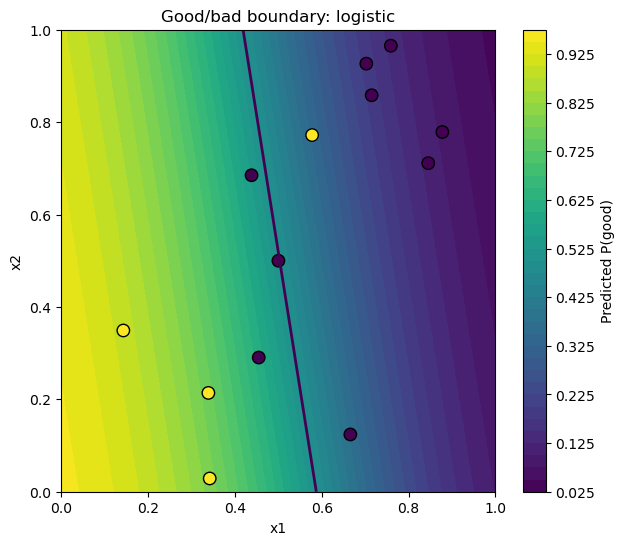

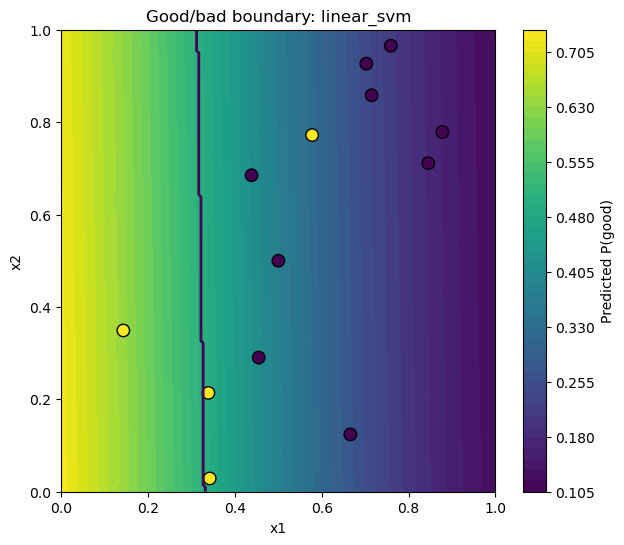

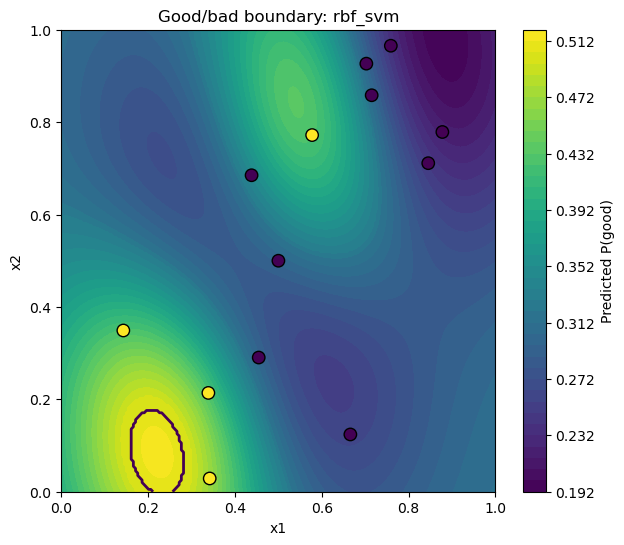

In [8]:
# Optional 2D plot
if d == 2 and len(np.unique(y_cls)) >= 2:
    grid_res = 200
    xx, yy = np.meshgrid(np.linspace(0, 1, grid_res), np.linspace(0, 1, grid_res))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    for name, model in models.items():
        prob = model.predict_proba(grid_scaled)[:, 1].reshape(grid_res, grid_res)
        plt.figure(figsize=(7, 6))
        cf = plt.contourf(xx, yy, prob, levels=40)
        plt.colorbar(cf, label="Predicted P(good)")
        plt.contour(xx, yy, prob, levels=[0.5], linewidths=2)
        plt.scatter(input_data[:, 0], input_data[:, 1], c=good_label, edgecolors="black", s=80)
        plt.xlabel("x1"); plt.ylabel("x2"); plt.title(f"Good/bad boundary: {name}")
        plt.show()
